# Electricity consumption given weather 
To get the data, unzip the zip file in this subdir, I can't push it to github and I have shot myself in the foot several times trying to. 
This is more or less a stress test, the data is not super difficult, but in its current sampling it just has a lot of points.

In [13]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import gpflow as gpf 
import numpy as np
import scipy.stats as ss
from tslearn.metrics import dtw

import matplotlib.pyplot as plt 
import tqdm as tqdm
import os

import sys
sys.path.append("../..")

from atmodel import ConditionalMOGP, SparseCMOGP
from atlikelihood import TransferLikelihood

def safe_float_conversion(v):
    try:
        v = float(v)
        return v
    except ValueError:
        return np.nan


ihepc = pd.read_csv("household_power_consumption.txt", sep=";", low_memory=False)
ihepc["Datetime"] = ihepc["Date"] + " "+ ihepc["Time"]
ihepc["Datetime"] = pd.to_datetime(ihepc["Datetime"])
ihepc.index = ihepc.Datetime
ihepc_weekly = ihepc["Global_active_power"].map(safe_float_conversion).resample("W").mean().bfill()
power_weekly = (ihepc_weekly - ihepc_weekly.mean()) / ihepc_weekly.std()

/tmp/ipykernel_5262/360063751.py:29: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  ihepc["Datetime"] = pd.to_datetime(ihepc["Datetime"])


In [14]:
def plot_gp(x, mu, var, color, label):
    plt.plot(x, mu, color=color, lw=2, label=label)
    plt.fill_between(
        x[:, 0],
        (mu - 2 * np.sqrt(var))[:, 0],
        (mu + 2 * np.sqrt(var))[:, 0],
        color=color,
        alpha=0.4,
    )


def plot(m):
    plt.figure(figsize=(14, 4))
    Xtest = np.linspace(0, 1, 100)[:, None]
    plt.plot(Ax, Ay, "x", color="C0", mew=2)
    mu, var = m.predict_f(np.hstack((Xtest, np.zeros_like(Xtest))))
    plot_gp(Xtest, mu, var, "C0", "Y1")

    plt.plot(Bx, By, "x",color="C1", mew=2)
    mu, var = m.predict_f(np.hstack((Xtest, np.ones_like(Xtest))))
    plot_gp(Xtest, mu, var, "C1", "Y2")
    plt.xlim([0, Ax[:,0].max()])
    plt.ylim([-5, 5])
    try:
        ivs = m.inducing_variable.Z.numpy() 
        plt.scatter(ivs, np.zeros_like(ivs)+2, marker="|", c=m.inducing_indices)
    except AttributeError:
        pass
    plt.legend()
    return mu


def optimize(m):
    opt = gpf.optimizers.Scipy()
    res = opt.minimize(m.training_loss, m.trainable_variables, track_loss_history=True, options={"disp": 50})
    plt.plot(res["loss_history"])
    plt.show()
 

In [15]:
weather = pd.read_csv("export.csv")
weather["date"] = pd.to_datetime(weather["date"])
weather.head()
weather.index = weather.date
weather_daily = weather.tavg.bfill().resample("2D").mean()
weather_daily = (weather_daily - weather_daily.mean())/weather_daily.std()

207 731


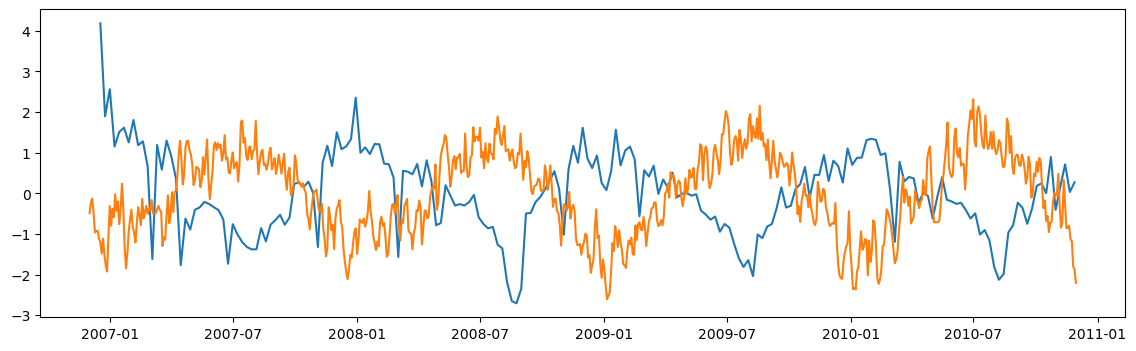

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(14, 4))
print(len(ihepc_weekly), len(weather_daily))
plt.plot(power_weekly)
plt.plot(weather_daily)
plt.show()

In [17]:
Bx = power_weekly.index.view("int64").reshape(-1, 1).astype(float)
By = power_weekly.values.reshape(-1, 1).astype(np.float64)
Ax = weather_daily.index.view("int64").reshape(-1, 1).astype(float)
Ay = weather_daily.values.reshape(-1, 1).astype(np.float64)
n_test = 12
Xtest, ytest = Bx[-n_test:], By[-n_test:]
print(Bx.shape, By.shape)
Bx, By = Bx[:-n_test,:], By[:-n_test,:]
print(Bx.shape, By.shape)
print(len(Xtest), len(ytest))
Xtest = (Xtest - Bx.min()) /(Bx.max() - Bx.min())
Ax = (Ax - Bx.min()) /(Bx.max() - Bx.min())
Bx = (Bx - Bx.min()) /(Bx.max() - Bx.min())
print(Ax.shape, Ay.shape, Bx.shape, By.shape)

X = np.vstack((np.hstack((Ax, np.zeros_like(Ax, dtype=np.int32))), np.hstack((Bx, np.ones_like(Bx, dtype=np.int32)))))
y = np.vstack((np.hstack((Ay, np.zeros_like(Ay, dtype=np.int32))), np.hstack((By, np.ones_like(By, dtype=np.int32)))))
Xtest = np.hstack((Xtest, np.ones_like(Xtest)))


(207, 1) (207, 1)
(195, 1) (195, 1)
12 12
(731, 1) (731, 1) (195, 1) (195, 1)


### CMOGP, takes about 1 minute with 20 ivs (100 is already much better, that takes 5 minutes or so) 

tf.Tensor(-282.61270826044466, shape=(), dtype=float64)
╒════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═════════╕
│ name                                           │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value   │
╞════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪═════════╡
│ SparseCMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0     │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────┤
│ SparseCMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 1.0     │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼───

2026-08-13 12:20:27.404946: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular output with NaNs.
2026-08-13 12:20:27.449875: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular output with NaNs.
2026-08-13 12:20:27.466890: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular output with NaNs.
2026-08-13 12:20:27.483874: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular output with NaNs.
2026-08-13 12:20:27.500022: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular out

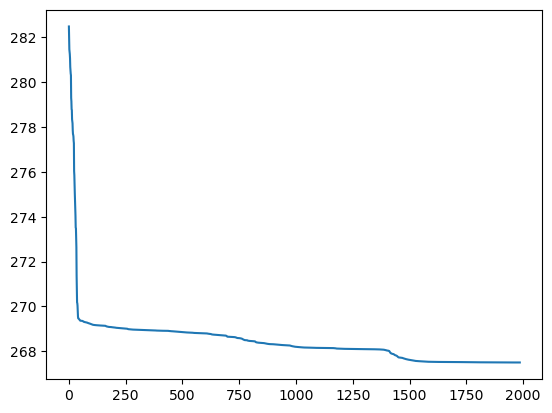

╒════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═════════════════════════════════╕
│ name                                           │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │ value                           │
╞════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪═════════════════════════════════╡
│ SparseCMOGP.kernel.kernels[0].variance         │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 0.0006419353915778441           │
├────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────────────────────────────┤
│ SparseCMOGP.kernel.kernels[0].lengthscales     │ Parameter │ Softplus         │         │ True        │ ()      │ float64 │ 0.375177257136309               │
├───────────────────────────────────────

In [24]:
output_dim = 2 # Number of outputs
k = gpf.kernels.RBF()
#k = gpf.kernels.Periodic(gpf.kernels.Matern32())
# Base kernel

# Coregion kernel
coreg1 = gpf.kernels.Coregion(output_dim=output_dim, rank=1, active_dims=[1])
ivs = np.linspace(0, max(Xtest[:,0]), 20).reshape(-1, 1)
iv_ind = np.concatenate((np.zeros((int(len(ivs)/2),1)), np.ones((int(len(ivs)/2),1))))
shuffle = np.random.permutation(np.arange(len(ivs)))
iv_ind = iv_ind[shuffle]
ivs = np.hstack((ivs, iv_ind))
kern = k * coreg1
m = SparseCMOGP((X, y), exact_target=False, kernel=kern, jitter=1e-4, inducing_variable=ivs, likelihood=TransferLikelihood(source=gpf.likelihoods.Gaussian(), target=gpf.likelihoods.Gaussian()))

print(m.maximum_log_likelihood_objective())

gpf.utilities.print_summary(m)
optimize(m)
gpf.utilities.print_summary(m)


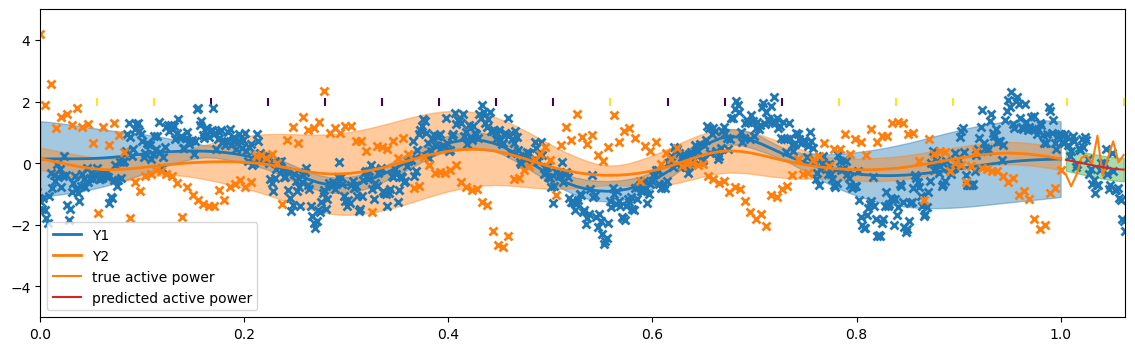

0.28682276937216583


In [19]:
plot(m)
mu2, var2 = m.predict_f(Xtest)
plt.plot(Xtest[:,0], ytest, color="C1", label="true active power")
plt.plot(Xtest[:,0], mu2, color="C3", label="predicted active power")
plt.fill_between(
        Xtest[:, 0],
        (mu2 - 2 * np.sqrt(var2))[:, 0],
        (mu2 + 2 * np.sqrt(var2))[:, 0],
        color="C2",
        alpha=0.4,
    )
plt.legend()
plt.show()
print(np.mean((mu2 - ytest)**2))


### Comparison to VGP (takes 10 minutes on my machine)

In [23]:
# This likelihood switches between Gaussian noise with different variances for each f_i:
output_dim = 2  # Number of outputs
rank = 1  # Rank of W
from robust_svgp import LMCInducingPointsBase

# Base kernel
k = gpf.kernels.Periodic(gpf.kernels.Matern32())
k = gpf.kernels.RBF()


# Coregion kernel
coreg = gpf.kernels.Coregion(
    output_dim=output_dim, rank=rank, active_dims=[1]
)

ivs = np.linspace(0, max(Xtest[:,0]), 20).reshape(-1, 1)
iv_ind = np.concatenate((np.zeros((int(len(ivs)/2),1)), np.ones((int(len(ivs)/2),1))))
iv_ind = iv_ind[shuffle]
ivs = np.hstack((ivs, iv_ind))

lik = gpf.likelihoods.SwitchedLikelihood(
    [gpf.likelihoods.Gaussian(), gpf.likelihoods.Gaussian()]
)
kern = k * coreg
# now build the GP model as normal
m = gpf.models.SVGP(kernel=kern, likelihood=lik, num_data=len(X), inducing_variable=LMCInducingPointsBase(ivs))
# fit the covariance function parameters
gpf.optimizers.Scipy().minimize(
    m.training_loss_closure((X, y)),
    m.trainable_variables,
    method="L-BFGS-B",
)

2026-08-13 12:20:02.740322: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/diag_part_grad/diag/diag_part/k' with dtype int32
	 [[{{node gradients/diag_part_grad/diag/diag_part/k}}]]
2026-08-13 12:20:02.802782: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2_grad/ReverseV2/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2/axis' with dtype int32 and shape [1]
	 [[{{node gradients/MatrixBandPart/fill_triangular_CONSTRUCTED_AT_top_level/forward/fill_triangular/ReverseV2_grad

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: 803.6537386567672
        x: [ 1.011e+00 -1.822e+00 ... -1.316e+00 -6.355e-01]
      nit: 405
      jac: [ 6.158e-05  6.450e-03 ... -8.975e-03  3.694e-03]
     nfev: 481
     njev: 481
 hess_inv: <238x238 LbfgsInvHessProduct with dtype=float64>

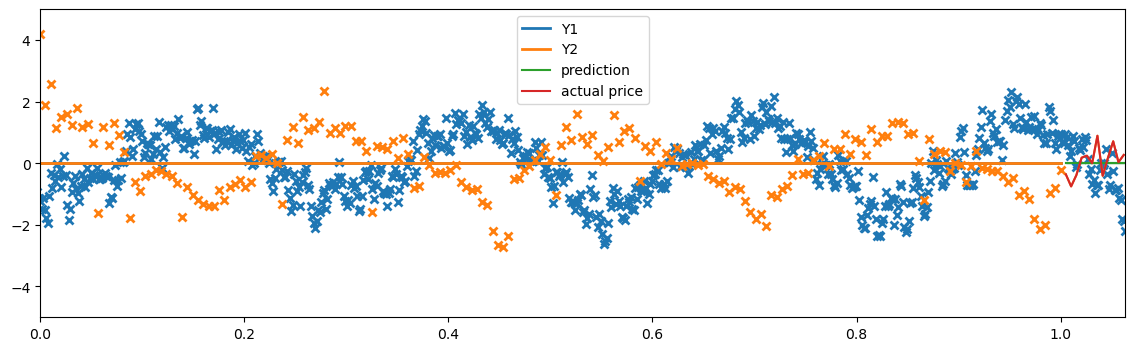

0.20925280342120403


In [21]:
plot(m)
mu, var = m.predict_f(Xtest)
plt.plot(Xtest[:,0], mu)
plt.plot(Xtest[:,0], ytest)
plt.plot(Xtest[:,0], mu, label="prediction")
plt.plot(Xtest[:,0], ytest, label="actual price")
plt.fill_between(
        Xtest[:, 0],
        (mu - 2 * np.sqrt(var))[:, 0],
        (mu + 2 * np.sqrt(var))[:, 0],
        color="C2",
        alpha=0.4,
    )
plt.legend()
plt.show()
print(np.mean((mu - ytest)**2))